In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import torch 
import torch.nn as nn
import torch.optim as optim #this is for the optimizer 
#to not get warnings when building the nn
import warnings
warnings.filterwarnings('ignore')
from torch.utils.data import Dataset, random_split, DataLoader, Subset 
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
emotions_df = pd.read_csv('/kaggle/input/speech-emotion-recognition-model-cnn-lstm-part-1/emotion.csv')
emotions_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotions
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302,surprise
1,0.249512,0.371094,0.494629,0.487305,0.450195,0.416992,0.373047,0.337402,0.333496,0.333008,...,1.221636,1.231226,4.829375,-2.660280,-2.523232,0.690448,-3.171180,-4.200538,0.267294,surprise
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.518293,0.838663,1.308726,1.855110,2.405185,2.896439,3.283485,3.541677,3.667470,surprise
3,0.257324,0.390625,0.510254,0.520020,0.499512,0.505859,0.493652,0.469238,0.480957,0.458496,...,-2.230192,0.787118,-3.272193,-2.678341,-4.033977,0.941363,3.609636,5.748407,5.765827,surprise
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749,neutral


In [4]:
emotions_df.isna().sum().sum()

28245624

In [5]:
X=emotions_df.iloc[:,:-1]
x=X.values
labels=labels=emotions_df['Emotions']
print(labels.head())
labels=labels.values

0    surprise
1    surprise
2    surprise
3    surprise
4     neutral
Name: Emotions, dtype: object


In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
#fit only the training data in standard scalar and OneHotEncoder and just transform the testing no prevent data leakage on our training data
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test= train_test_split(x, labels, test_size=0.2, random_state=42)

x_train=np.nan_to_num(x_train, nan=0.0)
x_test=np.nan_to_num(x_test, nan=0.0) #one way to deal with nan data in time series is to change nan=0
#(other ways can depend on the context on the sequence, all in all ,never drop the nan data)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

ohe=OneHotEncoder()
y_train=ohe.fit_transform(y_train.reshape(-1, 1))
y_test=ohe.transform(y_test.reshape(-1, 1))

In [7]:
class EmotionDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32).unsqueeze(1) 
        self.labels = torch.tensor(np.argmax(labels.toarray(), axis=1), dtype=torch.long)  # OneHot decoded

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.features[idx].unsqueeze(0)  #Shape: (1,features)
        y = self.labels[idx]
        return x, y
        

train_dataset= EmotionDataset(x_train, y_train)
test_dataset= EmotionDataset(x_test, y_test)

In [11]:
class CNN_LSTM(nn.Module):
    def __init__ (self, num_classes=7,dropout_rate=0.25,filter_size=(9,7,5)):
        super(CNN_LSTM,self).__init__()
        self.conv1=nn.Conv2d(1,64,kernel_size=(filter_size[0],filter_size[0]),stride=1,padding=(filter_size[0]//2,filter_size[0]//2))
        self.bn1=nn.BatchNorm2d(64)
        
        self.conv2=nn.Conv2d(64,128,kernel_size=(filter_size[1],filter_size[1]),padding=(filter_size[1]//2,filter_size[1]//2))
        #to normalize the values in a batch, helps with gradient flow and reduces overfitting
        self.bn2=nn.BatchNorm2d(128)
        
        self.conv3=nn.Conv1d(128,256,kernel_size=(filter_size[2],filter_size[2]),padding=(filter_size[2]//2,filter_size[2]//2))
        self.bn3=nn.BatchNorm2d(256)
        self.flatten = nn.Flatten(start_dim=2)
        
        self.lstm=nn.LSTM(input_size=128,hidden_size=128,batch_first=True,bidirectional=True)
        self.fc = nn.Linear(256,num_classes)
        self.drop = nn.Dropout(dropout_rate)

            
    def forward(self,x):
        x = F.elu(self.bn1(self.conv1(x)))
        x = F.elu(self.bn2(self.conv2(x)))
        x = self.drop(x)
        b,c,h,w = x.size()
        x = x.permute(0, 2, 3, 1).contiguous() 
        x = x.view(b,h*w,c) 
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.drop(x)
        x = self.fc(x)
        return x


In [ ]:
from sklearn.model_selection import KFold

filter_sizes=[(9,7,5), (7,5,3)]
kfold=KFold(n_splits=3, shuffle=True, random_state=42)

results={}
best_val_acc=0
best_filter=None
best_model_state=None
best_val_loss=None


for filter_size in filter_sizes:
    fold_accs=[]
    fold_losses=[]

    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):
        print(f"filter sizes for the 3 layers: {filter_size},fold {fold+1}")

        train_subset= Subset(train_dataset, train_idx)
        val_subset= Subset(train_dataset, val_idx)

        train_loader= DataLoader(train_subset, batch_size=32, shuffle=True)
        val_loader= DataLoader(val_subset, batch_size=32)

        model= CNN_LSTM(num_classes=7,dropout_rate=0.25,filter_size=filter_size).to(device)
        optimizer= optim.Adam(model.parameters(), lr=0.001)
        criterion= nn.CrossEntropyLoss()

        for epoch in range(15):
            model.train()
            for inputs,labels in train_loader:
                inputs,labels= inputs.to(device),labels.to(device)
                optimizer.zero_grad()
                outputs =model(inputs)
                loss=criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                best_model_state=model.state_dict()
            print(f"the loss: {loss.item():.3f}"," epoch number: ", epoch+1,)
            torch.save(model.state_dict(), f"{filter_size}_{fold}_latest_model.pt")

   
        model.eval()
        total, correct, val_loss = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs,labels=inputs.to(device), labels.to(device)
                outputs=model(inputs)
                loss=criterion(outputs, labels)
                val_loss+=loss.item()
                preds=outputs.argmax(dim=1)
                correct+=(preds==labels).sum().item()
                total+=labels.size(0)

        acc=correct/total
        fold_accs.append(acc)
        fold_losses.append(val_loss/len(val_loader))
        print(f"validation accuracy: {acc: .3f}")

    avg_acc=np.mean(fold_accs)
    avg_loss=np.mean(fold_losses)
    results[filter_size]=(avg_loss, avg_acc)

    if avg_acc > best_val_acc:
        best_val_acc=avg_acc
        best_val_loss=avg_loss
        best_filter=filter_size
        best_model_state=model.state_dict()

print("best filter size: ", best_filter," with accuracy of: ",best_val_acc, " and loss: ", best_val_loss)


filter sizes for the 3 layers: (9, 7, 5),fold 1
the loss: 1.942  epoch number:  1
the loss: 1.812  epoch number:  2
the loss: 1.988  epoch number:  3
the loss: 1.922  epoch number:  4
the loss: 1.898  epoch number:  5
the loss: 1.820  epoch number:  6
the loss: 1.903  epoch number:  7
the loss: 1.865  epoch number:  8
the loss: 1.885  epoch number:  9
the loss: 1.814  epoch number:  10
the loss: 1.871  epoch number:  11
the loss: 1.933  epoch number:  12
the loss: 1.980  epoch number:  13
the loss: 1.685  epoch number:  14
the loss: 1.859  epoch number:  15
validation accuracy:  0.245
filter sizes for the 3 layers: (9, 7, 5),fold 2
the loss: 1.842  epoch number:  1
the loss: 1.980  epoch number:  2
the loss: 1.775  epoch number:  3
the loss: 1.867  epoch number:  4
the loss: 1.783  epoch number:  5
the loss: 1.869  epoch number:  6
the loss: 1.993  epoch number:  7
the loss: 1.836  epoch number:  8
the loss: 1.796  epoch number:  9
the loss: 1.985  epoch number:  10
the loss: 1.887  ep

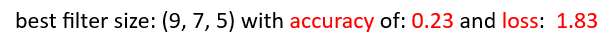